In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import urllib.request

In [ ]:

# wavelength axis - JWST NIRSpec range in microns
wavelength = np.linspace(0.6, 5.5, 500)

# baseline transit depth - flat atmosphere
baseline = 1.4  # percent

# CO2 feature at 4.3 microns - the famous JWST detection
co2 = 0.25 * np.exp(-((wavelength - 4.3)**2) / (2 * 0.1**2))

# water features - broader, multiple locations
water1 = 0.15 * np.exp(-((wavelength - 1.4)**2) / (2 * 0.15**2))
water2 = 0.12 * np.exp(-((wavelength - 1.9)**2) / (2 * 0.12**2))
water3 = 0.10 * np.exp(-((wavelength - 2.7)**2) / (2 * 0.20**2))

# add noise - real data is noisy
noise = np.random.normal(0, 0.03, wavelength.shape)

# combined spectrum
depth = baseline + co2 + water1 + water2 + water3 + noise

plt.figure(figsize=(12, 5))
plt.plot(wavelength, depth, color='steelblue', linewidth=1)
plt.xlabel("Wavelength (microns)")
plt.ylabel("Transit depth (%)")
plt.title("WASP-39b — simulated transmission spectrum")
plt.grid(alpha=0.3)
plt.show()


1.4 is water, 4.2 is carbon dioxide!! first CO2 detection! omg!
Here's where it gets interesting. Now, we derive individual signals from this graph. 
Kind of like having a master track and solo-ing diff instruments out. 

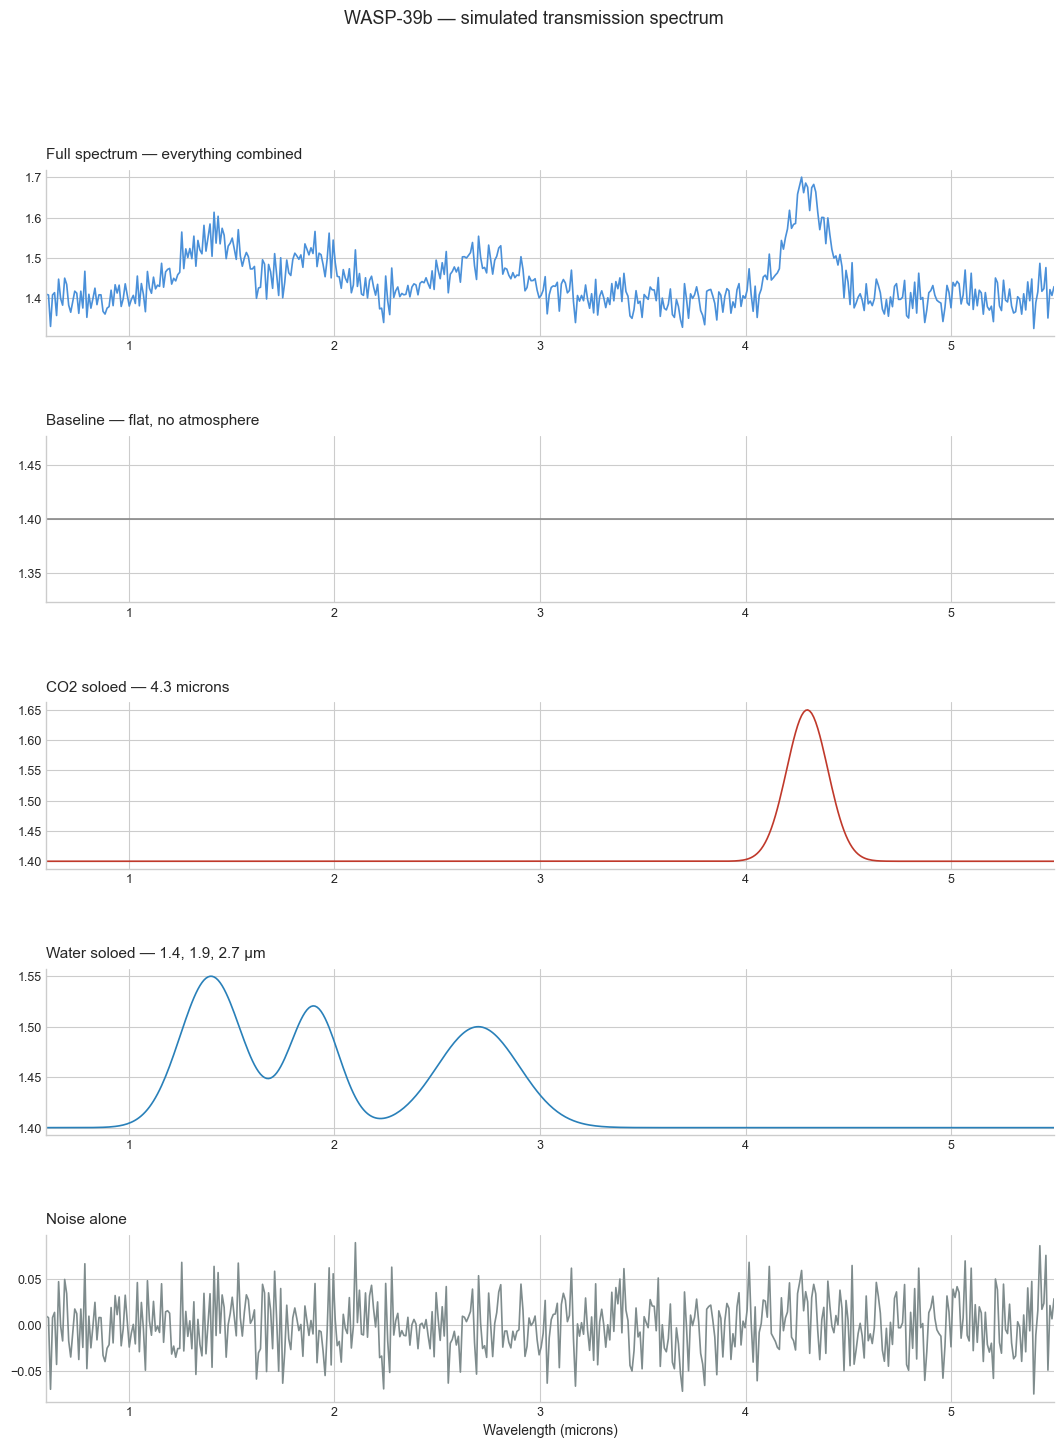

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.style.use('seaborn-v0_8-whitegrid')

wavelength = np.linspace(0.6, 5.5, 500)
baseline_val = 1.4

co2   = 0.25 * np.exp(-((wavelength - 4.3)**2) / (2 * 0.10**2))
w1    = 0.15 * np.exp(-((wavelength - 1.4)**2) / (2 * 0.15**2))
w2    = 0.12 * np.exp(-((wavelength - 1.9)**2) / (2 * 0.12**2))
w3    = 0.10 * np.exp(-((wavelength - 2.7)**2) / (2 * 0.20**2))
noise = np.random.normal(0, 0.03, wavelength.shape)
water = w1 + w2 + w3

baseline = np.ones_like(wavelength) * baseline_val
full     = baseline + co2 + water + noise

panels = [
    ("Full spectrum — everything combined", full,           "#4a90d9"),
    ("Baseline — flat, no atmosphere",      baseline,       "#888888"),
    ("CO2 soloed — 4.3 microns",           baseline + co2, "#c0392b"),
    ("Water soloed — 1.4, 1.9, 2.7 μm",   baseline+water, "#2980b9"),
    ("Noise alone",                         noise,          "#7f8c8d"),
]

fig = plt.figure(figsize=(13, 16))
gs  = gridspec.GridSpec(5, 1, hspace=0.6)

for i, (title, data, color) in enumerate(panels):
    ax = fig.add_subplot(gs[i])
    ax.plot(wavelength, data, color=color, linewidth=1.2)
    ax.set_title(title, fontsize=11, fontweight='normal', loc='left', pad=8)
    ax.set_xlim(wavelength.min(), wavelength.max())
    ax.tick_params(labelsize=9)
    ax.spines[['top','right']].set_visible(False)
    if i == len(panels) - 1:
        ax.set_xlabel("Wavelength (microns)", fontsize=10)

plt.suptitle("WASP-39b — simulated transmission spectrum", 
             fontsize=13, fontweight='normal', y=0.98)
plt.savefig("wasp39b_spectrum.png", dpi=150, bbox_inches='tight')
plt.show()

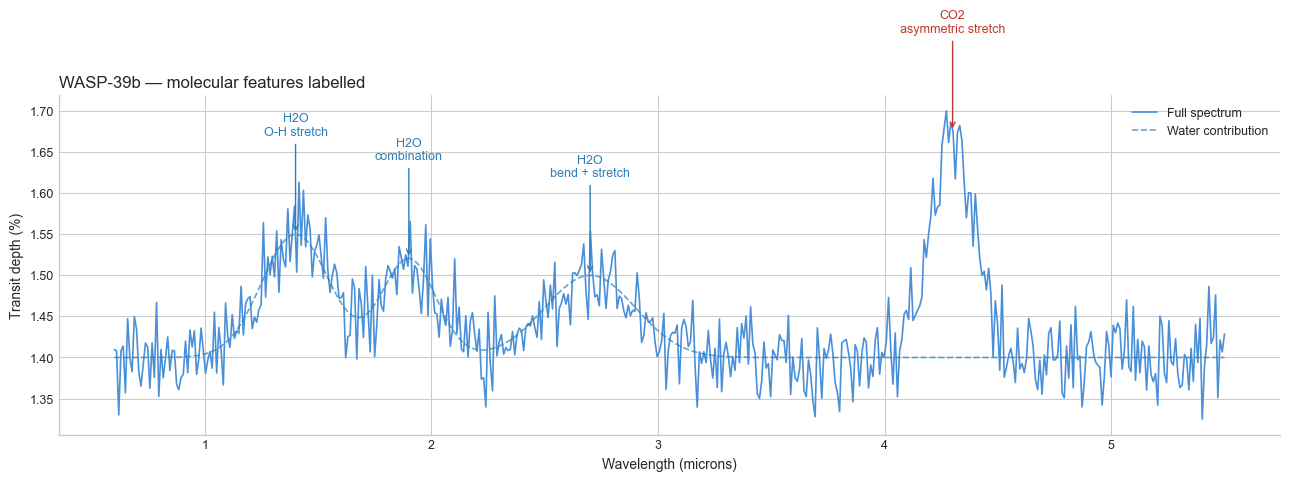

In [12]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(wavelength, full, color='#4a90d9', linewidth=1.2, label='Full spectrum')
ax.plot(wavelength, baseline + water, color='#2980b9', linewidth=1.2, 
        linestyle='--', alpha=0.7, label='Water contribution')

# water peak labels
water_peaks = [(1.4, 'H2O\nO-H stretch'), 
               (1.9, 'H2O\ncombination'), 
               (2.7, 'H2O\nbend + stretch')]

for wl_peak, label in water_peaks:
    idx = np.argmin(np.abs(wavelength - wl_peak))
    peak_val = (baseline + water)[idx]
    ax.annotate(label,
                xy=(wl_peak, peak_val),
                xytext=(wl_peak, peak_val + 0.12),
                ha='center', fontsize=9,
                color='#2980b9',
                arrowprops=dict(arrowstyle='->', color='#2980b9', lw=1))

# CO2 label
idx_co2 = np.argmin(np.abs(wavelength - 4.3))
co2_val = full[idx_co2]
ax.annotate('CO2\nasymmetric stretch',
            xy=(4.3, co2_val),
            xytext=(4.3, co2_val + 0.12),
            ha='center', fontsize=9,
            color='#c0392b',
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1))

ax.set_xlabel('Wavelength (microns)', fontsize=10)
ax.set_ylabel('Transit depth (%)', fontsize=10)
ax.set_title('WASP-39b — molecular features labelled', 
             fontsize=12, fontweight='normal', loc='left')
ax.legend(fontsize=9, framealpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=9)

plt.tight_layout()
plt.savefig('wasp39b_labelled.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/gl/pb31_0s17tzfqmv3rstwv96c0000gn/T/ipykernel_73928/1019370215.py:56: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig('wasp39b_water_soloed.png', dpi=150, bbox_inches='tight')


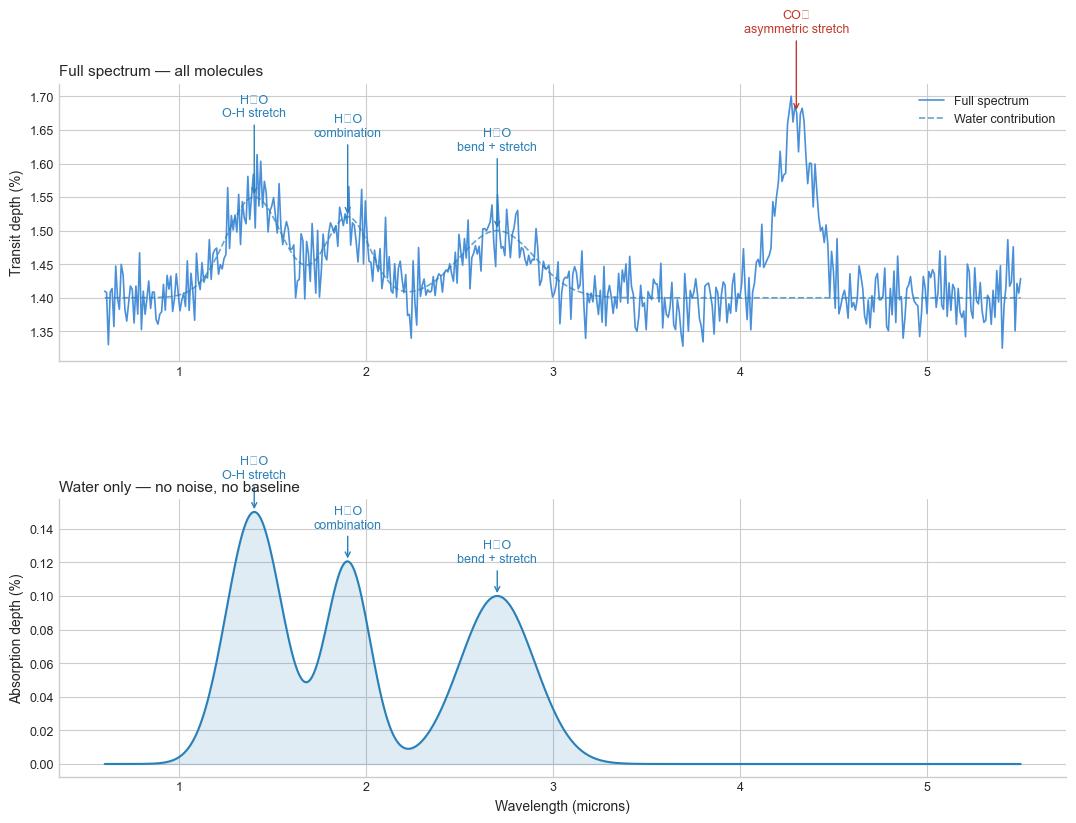

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), gridspec_kw={'hspace': 0.5})

# top panel — full spectrum labelled
ax = axes[0]
ax.plot(wavelength, full, color='#4a90d9', linewidth=1.2, label='Full spectrum')
ax.plot(wavelength, baseline + water, color='#2980b9', linewidth=1.2,
        linestyle='--', alpha=0.7, label='Water contribution')

water_peaks = [(1.4, 'H₂O\nO-H stretch'),
               (1.9, 'H₂O\ncombination'),
               (2.7, 'H₂O\nbend + stretch')]

for wl_peak, label in water_peaks:
    idx = np.argmin(np.abs(wavelength - wl_peak))
    peak_val = (baseline + water)[idx]
    ax.annotate(label,
                xy=(wl_peak, peak_val),
                xytext=(wl_peak, peak_val + 0.12),
                ha='center', fontsize=9, color='#2980b9',
                arrowprops=dict(arrowstyle='->', color='#2980b9', lw=1))

idx_co2 = np.argmin(np.abs(wavelength - 4.3))
co2_val = full[idx_co2]
ax.annotate('CO₂\nasymmetric stretch',
            xy=(4.3, co2_val),
            xytext=(4.3, co2_val + 0.12),
            ha='center', fontsize=9, color='#c0392b',
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1))

ax.set_ylabel('Transit depth (%)', fontsize=10)
ax.set_title('Full spectrum — all molecules', fontsize=11, fontweight='normal', loc='left')
ax.legend(fontsize=9, framealpha=0.4)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(labelsize=9)

# bottom panel — water only, clean, no noise
ax2 = axes[1]
ax2.plot(wavelength, water, color='#2980b9', linewidth=1.5)
ax2.fill_between(wavelength, water, alpha=0.15, color='#2980b9')

for wl_peak, label in water_peaks:
    idx = np.argmin(np.abs(wavelength - wl_peak))
    peak_val = water[idx]
    ax2.annotate(label,
                 xy=(wl_peak, peak_val),
                 xytext=(wl_peak, peak_val + 0.02),
                 ha='center', fontsize=9, color='#2980b9',
                 arrowprops=dict(arrowstyle='->', color='#2980b9', lw=1))

ax2.set_xlabel('Wavelength (microns)', fontsize=10)
ax2.set_ylabel('Absorption depth (%)', fontsize=10)
ax2.set_title('Water only — no noise, no baseline', fontsize=11, fontweight='normal', loc='left')
ax2.spines[['top', 'right']].set_visible(False)
ax2.tick_params(labelsize=9)

plt.savefig('wasp39b_water_soloed.png', dpi=150, bbox_inches='tight')
plt.show()

In [3]:
import h5py
with h5py.File('W39_PRISM_data/transit_spectra/FIREFLy_transit_spec.h5', 'r') as f:
    def print_structure(name, obj):
        print(name)
    f.visititems(print_structure)

transit_depth
transit_depth_uncertainty
wavelength
